In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import time
import torch 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyro.distributions as dist
from torch.distributions import Normal
mpl.rcdefaults()   # rcParams をデフォルトに戻す
from nle_arhmm import NFlowAR1HMMEstimator, NLEEstimator
from dynamics import LotkaVolterraDynamics
from data_generation import (SwitchingSDEDataGenerator,
                             generate_true_and_obs_data,
                             generate_data_of_state)
from visualization import plot_log_prob_contour, plot_series_multi
from utils import create_ground_truth_parameters

/home/shion/Dropbox/Study/Experiment/FNSE_SSDE/.venv/FNLE_ARHMM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
"""Settings"""
seed = 42
torch.manual_seed(seed)
dynamics = LotkaVolterraDynamics()

# Initial observation
X0 = torch.tensor([1.0, 0.5], dtype=torch.float32)

# Create ground truth parameters
hmm_param_true = create_ground_truth_parameters()

# Generate observations
num_series = 5
T_obs = 2000
obs_interval = 50  # Subsample observations
n_steps_for_each_interval = T_obs // obs_interval

In [5]:
print("\nGenerating observation data...")
generator = SwitchingSDEDataGenerator(dynamics)
X_obs, Z_obs, X_true, Z_true, obs_idx_list = generate_true_and_obs_data(
    generator, num_series, hmm_param_true, T_obs, X0, obs_interval)

# Concatenate all observations for training
X_all = torch.cat(X_obs, dim=0)

# Train NLE
print("\nTraining NLE estimator...")
# ズル
sampling_dist = dist.MultivariateNormal(
    hmm_param_true['emissions'][0],
    0.3 * torch.eye(dynamics.theta_dim).to(device)
)
# sampling_dist = dist.MultivariateNormal(
#     torch.zeros_like(hmm_param_true).to(config.device),
#     0.3 * torch.eye(hmm_param_truetruetruetrue.shape[0]).to(config.device)
# )
nle = NLEEstimator(dynamics, sampling_dist=sampling_dist)
_ = nle.train(
    x_ref=X_all,
    n_params=50,
    n_steps=obs_interval,
    batch_size=256,
    lr=5e-4,
    epochs=50
)
 


Generating observation data...
  Series 1: 40 observations
  Series 2: 40 observations
  Series 3: 40 observations
  Series 4: 40 observations
  Series 5: 40 observations

Training NLE estimator...
Generating training data from 50 parameter samples...


100%|██████████| 50/50 [00:47<00:00,  1.05it/s]


Data generation took 47.82s,samples: 9950
Training NLE estimator...
 Training neural network. Epochs trained: 51
NLE training took 44.41s


In [12]:
X_obs_concat = torch.concat(X_obs).clone()

In [13]:
state = 1
# X^*
targets = generate_data_of_state(nle, state, hmm_param_true, X_obs_concat,
                                 n_steps_for_each_interval)

100it [01:23,  1.20it/s]


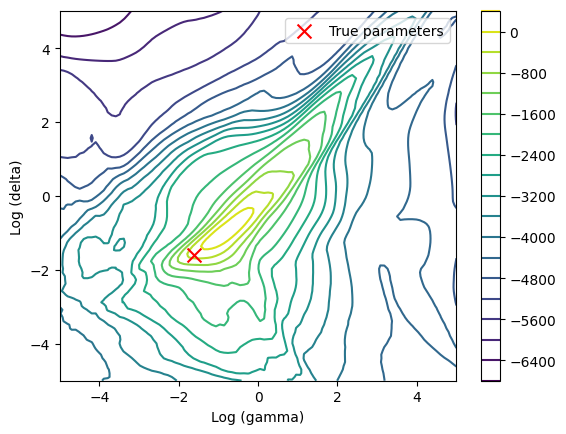

In [14]:
theta_idx_as_x = 2
theta_idx_as_y = 3
plot_log_prob_contour(nle, state, hmm_param_true, X_obs_concat, targets, theta_idx_as_x, theta_idx_as_y)